# Figure 2 — Chemical Class Distributions

Violin and lollipop plots showing how NPC chemical classes change upon fermentation in cassava and cocoyam. Violin plots display intensity distributions per class; lollipop plots show median log2 fold-change. Only features with CANOPUS classification probability ≥ 0.64 are included. Statistical significance is assessed by Mann-Whitney U tests with Benjamini-Hochberg correction.

**Output:** `figure2_standardized.svg / .png`

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from upsetplot import UpSet, from_memberships
from matplotlib_venn import venn2, venn2_circles
import os

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'sans-serif'

# Output directory
OUTPUT_DIR = '../figures/separate_treatment'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Analysis parameters
PROB_CUTOFF = 0.7
FDR_CUTOFF = 0.05
LOG2FC_THRESHOLD = 1.0

print(f"Output directory: {OUTPUT_DIR}")
print(f"Probability cutoff: {PROB_CUTOFF}")
print(f"FDR cutoff: {FDR_CUTOFF}")
print(f"log2FC threshold: {LOG2FC_THRESHOLD}")

Output directory: ../figures/separate_treatment
Probability cutoff: 0.7
FDR cutoff: 0.05
log2FC threshold: 1.0


In [64]:
# ── Load cassava-only data ─────────────────────────────────────────────────────
cassava_quant = pd.read_csv('../results/b3_cassavaonly_feature_list_imputed_log2.csv')
cassava_fdr = pd.read_csv('../results/b3_cassavaonly_fdr_cassava_vs_fermented_cassava.csv')
cassava_ms2 = pd.read_csv('../results/b3_cassavaonly_ms2_annotations.csv')

# ── Load cocoyam-only data ─────────────────────────────────────────────────────
cocoyam_quant = pd.read_csv('../results/b3_cocoyamonly_feature_list_imputed_log2.csv')
cocoyam_fdr = pd.read_csv('../results/b3_cocoyamonly_fdr_cocoyam_vs_fermented_cocoyam.csv')
cocoyam_ms2 = pd.read_csv('../results/b3_cocoyamonly_ms2_annotations.csv')

print("=== Cassava-only data ===")
print(f"  Features: {len(cassava_quant):,}")
print(f"  FDR results: {len(cassava_fdr):,}")
print(f"  MS2 annotations: {len(cassava_ms2):,}")

print("\n=== Cocoyam-only data ===")
print(f"  Features: {len(cocoyam_quant):,}")
print(f"  FDR results: {len(cocoyam_fdr):,}")
print(f"  MS2 annotations: {len(cocoyam_ms2):,}")

=== Cassava-only data ===
  Features: 3,324
  FDR results: 3,324
  MS2 annotations: 1,482

=== Cocoyam-only data ===
  Features: 4,437
  FDR results: 4,437
  MS2 annotations: 1,840


In [65]:
# ── Merge FDR results with MS2 annotations ─────────────────────────────────────
# Cassava
cassava_merged = cassava_fdr.merge(
    cassava_ms2.rename(columns={'mappingFeatureId': 'id'}),
    on='id',
    how='left'
)

# Cocoyam
cocoyam_merged = cocoyam_fdr.merge(
    cocoyam_ms2.rename(columns={'mappingFeatureId': 'id'}),
    on='id',
    how='left'
)

print(f"Cassava merged: {len(cassava_merged):,} features")
print(f"  With MS2 annotation: {cassava_merged['sirius_name'].notna().sum():,}")
print(f"\nCocoyam merged: {len(cocoyam_merged):,} features")
print(f"  With MS2 annotation: {cocoyam_merged['sirius_name'].notna().sum():,}")

Cassava merged: 3,324 features
  With MS2 annotation: 638

Cocoyam merged: 4,437 features
  With MS2 annotation: 921


In [66]:
# ── Classification levels ──────────────────────────────────────────────────────
CLASS_LEVELS = [
    ("sirius_NPC#pathway",              "sirius_NPC#pathway Probability",                  "NPC pathway"),
    ("sirius_NPC#superclass",           "sirius_NPC#superclass Probability",               "NPC superclass"),
    ("sirius_NPC#class",                "sirius_NPC#class Probability",                    "NPC class"),
    ("sirius_ClassyFire#superclass",    "sirius_ClassyFire#superclass probability",        "CF superclass"),
    ("sirius_ClassyFire#class",         "sirius_ClassyFire#class Probability",             "CF class"),
]

print("Classification levels:")
for col, prob_col, label in CLASS_LEVELS:
    print(f"  - {label}")

Classification levels:
  - NPC pathway
  - NPC superclass
  - NPC class
  - CF superclass
  - CF class


In [67]:
# ── Merge quant data with MS2 annotations for violin plots ─────────────────────
# Cassava: merge quant with ms2
cassava_violin_data = cassava_quant.merge(
    cassava_ms2.rename(columns={'mappingFeatureId': 'id'}),
    on='id',
    how='inner'
)

# Cocoyam: merge quant with ms2
cocoyam_violin_data = cocoyam_quant.merge(
    cocoyam_ms2.rename(columns={'mappingFeatureId': 'id'}),
    on='id',
    how='inner'
)

print(f"Cassava violin data: {len(cassava_violin_data):,} features")
print(f"Cocoyam violin data: {len(cocoyam_violin_data):,} features")

Cassava violin data: 1,428 features
Cocoyam violin data: 1,839 features


Valid pathways with ≥5 features in all conditions: 7
Pathways: ['Carbohydrates', 'Fatty acids', 'Terpenoids', 'Alkaloids', 'Amino acids and Peptides', 'Shikimates and Phenylpropanoids', 'Polyketides']


/tmp/ipykernel_94131/624632643.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved: ../figures/separate_treatment/npc_pathway_violin_tworows.svg


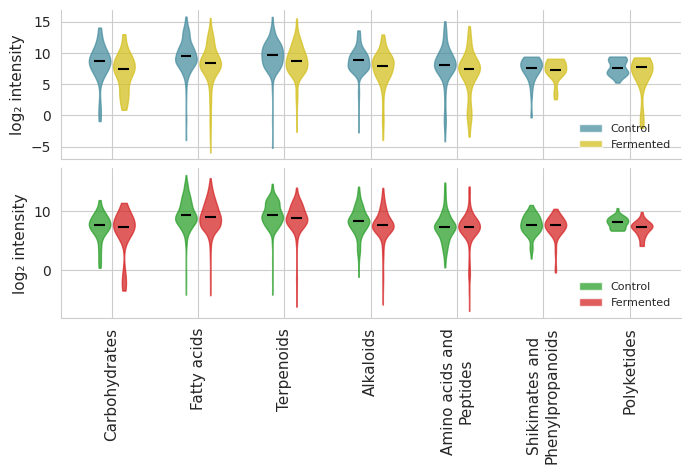

In [68]:
# ── NPC Pathway Violin Plot (Two Rows) ──────────────────────────────────────────
import textwrap
from matplotlib.patches import Patch

# Config
class_col   = "sirius_NPC#pathway"
prob_col    = "sirius_NPC#pathway Probability"
MIN_N       = 5

# Sample columns
cassava_ctrl_cols = [f"CSF_1_rep_{r}_norm_log2" for r in (1,2,3)]
cassava_ferm_cols = [f"CSF_2_rep_{r}_norm_log2" for r in (1,2,3)]
cocoyam_ctrl_cols = [f"CYF_1_rep_{r}_norm_log2" for r in (1,2,3)]
cocoyam_ferm_cols = [f"CYF_2_rep_{r}_norm_log2" for r in (1,2,3)]

rows_def = [
    {
        "label"  : "Cassava",
        "source" : cassava_violin_data,
        "ctrl"   : cassava_ctrl_cols,
        "ferm"   : cassava_ferm_cols,
        "colors" : ["#4A8FA0", "#D4C020"],
    },
    {
        "label"  : "Cocoyam",
        "source" : cocoyam_violin_data,
        "ctrl"   : cocoyam_ctrl_cols,
        "ferm"   : cocoyam_ferm_cols,
        "colors" : ["#2ca02c", "#d62728"],
    },
]

# Build long-form data
def build_long(source, cols, class_col, prob_col):
    sub = source[
        (pd.to_numeric(source[prob_col], errors='coerce') >= PROB_CUTOFF) &
        (source[class_col].notna()) & (source[class_col] != "")
    ][[class_col] + cols].copy()
    long = sub.melt(id_vars=class_col, value_vars=cols, value_name="intensity")
    long["intensity"] = pd.to_numeric(long["intensity"], errors="coerce")
    return long.dropna(subset=["intensity"])

for row in rows_def:
    row["ctrl_long"] = build_long(row["source"], row["ctrl"], class_col, prob_col)
    row["ferm_long"] = build_long(row["source"], row["ferm"], class_col, prob_col)

# Pathway order: sorted by cassava median difference
all_pathways = set(rows_def[0]["ctrl_long"][class_col].unique()) | \
               set(rows_def[0]["ferm_long"][class_col].unique())

valid_pathways = [
    p for p in all_pathways
    if all(
        (row[k][class_col] == p).sum() >= MIN_N
        for row in rows_def
        for k in ["ctrl_long", "ferm_long"]
    )
]

def median_diff(p):
    ctrl = rows_def[0]["ctrl_long"].loc[rows_def[0]["ctrl_long"][class_col] == p, "intensity"]
    ferm = rows_def[0]["ferm_long"].loc[rows_def[0]["ferm_long"][class_col] == p, "intensity"]
    return ferm.median() - ctrl.median()

pathway_order = sorted(valid_pathways, key=median_diff)
n = len(pathway_order)

print(f"Valid pathways with ≥{MIN_N} features in all conditions: {n}")
print(f"Pathways: {pathway_order}")

# Plot
fig, axes = plt.subplots(2, 1,
                         figsize=(max(8, n * 0.6), 4),
                         sharex=True,
                         gridspec_kw={"hspace": 0.06})

centres = np.arange(n) * 3.2

for ax, row in zip(axes, rows_def):
    for gi, pathway in enumerate(pathway_order):
        for ti, (key, color) in enumerate(zip(["ctrl_long", "ferm_long"], row["colors"])):
            vals = row[key].loc[row[key][class_col] == pathway, "intensity"].values
            if len(vals) < 2:
                continue
            pos = centres[gi] + (ti - 0.5) * 0.9
            parts = ax.violinplot([vals], positions=[pos],
                                  widths=0.8,
                                  showmeans=False, showmedians=True, showextrema=False)
            for pc in parts["bodies"]:
                pc.set_facecolor(color)
                pc.set_edgecolor(color)
                pc.set_alpha(0.75)
            parts["cmedians"].set_color("black")
            parts["cmedians"].set_linewidth(1.5)

    ax.set_ylabel("log₂ intensity", fontsize=11)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(
        handles=[Patch(facecolor=c, alpha=0.75, label=l)
                 for c, l in zip(row["colors"], ["Control", "Fermented"])],
        fontsize=8, frameon=False, loc="lower right"
    )

axes[1].set_xticks(centres)
axes[1].set_xticklabels(
    [textwrap.fill(p, width=16) for p in pathway_order],
    rotation=90, ha="center", fontsize=11
)

fig.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/npc_pathway_violin_tworows.svg', format='svg', bbox_inches='tight')
fig.savefig(f'{OUTPUT_DIR}/npc_pathway_violin_tworows.png', dpi=300, bbox_inches='tight')
print(f"Saved: {OUTPUT_DIR}/npc_pathway_violin_tworows.svg")
plt.show()

Valid pathways with ≥5 features in all conditions: 8
Pathways: ['Organic oxygen compounds', 'Lipids and lipid-like molecules', 'Organoheterocyclic compounds', 'Organic acids and derivatives', 'Phenylpropanoids and polyketides', 'Benzenoids', 'Organic nitrogen compounds', 'Nucleosides, nucleotides, and analogues']


/tmp/ipykernel_94131/1759453809.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved: ../figures/separate_treatment/cf_violin_tworows.svg


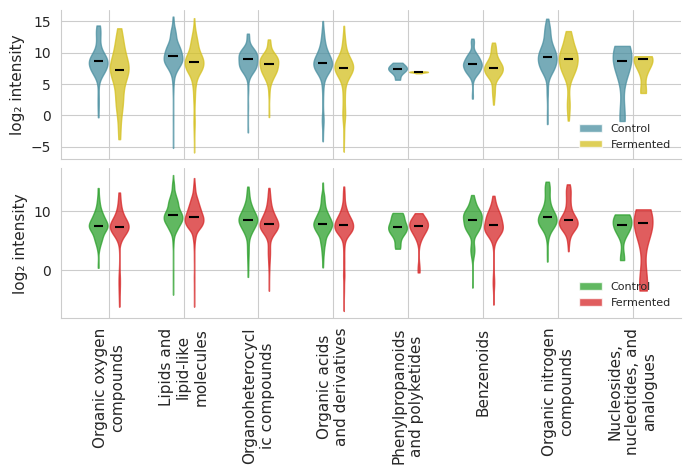

In [69]:
# ── NPC Pathway Violin Plot (Two Rows) ──────────────────────────────────────────
import textwrap
from matplotlib.patches import Patch

# Config
class_col   = "sirius_ClassyFire#superclass"
prob_col    = "sirius_ClassyFire#superclass probability"
MIN_N       = 5

# Sample columns
cassava_ctrl_cols = [f"CSF_1_rep_{r}_norm_log2" for r in (1,2,3)]
cassava_ferm_cols = [f"CSF_2_rep_{r}_norm_log2" for r in (1,2,3)]
cocoyam_ctrl_cols = [f"CYF_1_rep_{r}_norm_log2" for r in (1,2,3)]
cocoyam_ferm_cols = [f"CYF_2_rep_{r}_norm_log2" for r in (1,2,3)]

rows_def = [
    {
        "label"  : "Cassava",
        "source" : cassava_violin_data,
        "ctrl"   : cassava_ctrl_cols,
        "ferm"   : cassava_ferm_cols,
        "colors" : ["#4A8FA0", "#D4C020"],
    },
    {
        "label"  : "Cocoyam",
        "source" : cocoyam_violin_data,
        "ctrl"   : cocoyam_ctrl_cols,
        "ferm"   : cocoyam_ferm_cols,
        "colors" : ["#2ca02c", "#d62728"],
    },
]

# Build long-form data
def build_long(source, cols, class_col, prob_col):
    sub = source[
        (pd.to_numeric(source[prob_col], errors='coerce') >= PROB_CUTOFF) &
        (source[class_col].notna()) & (source[class_col] != "")
    ][[class_col] + cols].copy()
    long = sub.melt(id_vars=class_col, value_vars=cols, value_name="intensity")
    long["intensity"] = pd.to_numeric(long["intensity"], errors="coerce")
    return long.dropna(subset=["intensity"])

for row in rows_def:
    row["ctrl_long"] = build_long(row["source"], row["ctrl"], class_col, prob_col)
    row["ferm_long"] = build_long(row["source"], row["ferm"], class_col, prob_col)

# Pathway order: sorted by cassava median difference
all_pathways = set(rows_def[0]["ctrl_long"][class_col].unique()) | \
               set(rows_def[0]["ferm_long"][class_col].unique())

valid_pathways = [
    p for p in all_pathways
    if all(
        (row[k][class_col] == p).sum() >= MIN_N
        for row in rows_def
        for k in ["ctrl_long", "ferm_long"]
    )
]

def median_diff(p):
    ctrl = rows_def[0]["ctrl_long"].loc[rows_def[0]["ctrl_long"][class_col] == p, "intensity"]
    ferm = rows_def[0]["ferm_long"].loc[rows_def[0]["ferm_long"][class_col] == p, "intensity"]
    return ferm.median() - ctrl.median()

pathway_order = sorted(valid_pathways, key=median_diff)
n = len(pathway_order)

print(f"Valid pathways with ≥{MIN_N} features in all conditions: {n}")
print(f"Pathways: {pathway_order}")

# Plot
fig, axes = plt.subplots(2, 1,
                         figsize=(max(8, n * 0.6), 4),
                         sharex=True,
                         gridspec_kw={"hspace": 0.06})

centres = np.arange(n) * 3.2

for ax, row in zip(axes, rows_def):
    for gi, pathway in enumerate(pathway_order):
        for ti, (key, color) in enumerate(zip(["ctrl_long", "ferm_long"], row["colors"])):
            vals = row[key].loc[row[key][class_col] == pathway, "intensity"].values
            if len(vals) < 2:
                continue
            pos = centres[gi] + (ti - 0.5) * 0.9
            parts = ax.violinplot([vals], positions=[pos],
                                  widths=0.8,
                                  showmeans=False, showmedians=True, showextrema=False)
            for pc in parts["bodies"]:
                pc.set_facecolor(color)
                pc.set_edgecolor(color)
                pc.set_alpha(0.75)
            parts["cmedians"].set_color("black")
            parts["cmedians"].set_linewidth(1.5)

    ax.set_ylabel("log₂ intensity", fontsize=11)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(
        handles=[Patch(facecolor=c, alpha=0.75, label=l)
                 for c, l in zip(row["colors"], ["Control", "Fermented"])],
        fontsize=8, frameon=False, loc="lower right"
    )

axes[1].set_xticks(centres)
axes[1].set_xticklabels(
    [textwrap.fill(p, width=16) for p in pathway_order],
    rotation=90, ha="center", fontsize=11
)

fig.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/cf_violin_tworows.svg', format='svg', bbox_inches='tight')
fig.savefig(f'{OUTPUT_DIR}/cf_violin_tworows.png', dpi=300, bbox_inches='tight')
print(f"Saved: {OUTPUT_DIR}/cf_violin_tworows.svg")
plt.show()

NPC class comparisons: 71
      tuber                      npc_class  n_ctrl  n_ferm  median_ctrl  median_ferm  median_diff  mean_ctrl  mean_ferm  mean_diff    pval
6   Cassava                     Dipeptides      24      24         8.08         2.80        -5.28       8.30       3.48      -4.81  0.0000
10  Cassava         Glycerophosphocholines      69      69        10.47         8.64        -1.83      10.71       8.01      -2.70  0.0000
5   Cassava                Diacylglycerols      51      51        10.23         7.90        -2.33       9.66       6.22      -3.45  0.0001
11  Cassava    Glycerophosphoethanolamines      21      21         9.80         8.15        -1.65      10.02       8.28      -1.74  0.0014
13  Cassava                   Hydrocarbons       6       6         8.56         7.76        -0.80       8.65       7.79      -0.86  0.0022
9   Cassava              Glycerophosphates       9       9         8.31         7.42        -0.89       8.39       6.89      -1.50  0.0027
1

/tmp/ipykernel_94131/3502764473.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()



Saved: ../figures/separate_treatment/npc_class_lollipop_sidebyside.svg


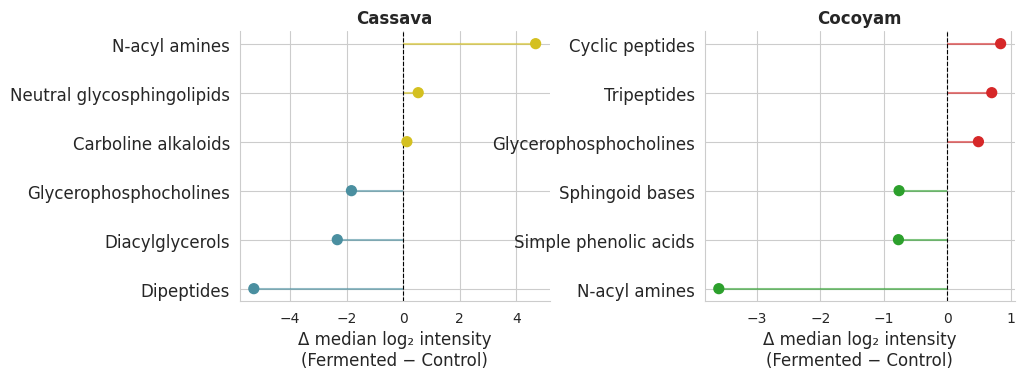

In [70]:
# ── NPC Class Lollipop Plots (Side-by-Side) ─────────────────────────────────────
from scipy.stats import mannwhitneyu

# Config
class_col_npc = "sirius_NPC#class"
prob_col_npc  = "sirius_NPC#class Probability"
MIN_N_LOLLIPOP = 5
TOP_N         = 3  # top 3 enriched and top 3 depleted

tuber_config = {
    "Cassava": {
        "source": cassava_violin_data,
        "ctrl"  : cassava_ctrl_cols,
        "ferm"  : cassava_ferm_cols,
    },
    "Cocoyam": {
        "source": cocoyam_violin_data,
        "ctrl"  : cocoyam_ctrl_cols,
        "ferm"  : cocoyam_ferm_cols,
    },
}

# Mann-Whitney per NPC class per tuber
results = []
for tuber, cfg in tuber_config.items():
    sub = cfg["source"][
        (pd.to_numeric(cfg["source"][prob_col_npc], errors='coerce') >= PROB_CUTOFF) &
        (cfg["source"][class_col_npc].notna()) &
        (cfg["source"][class_col_npc] != "")
    ].copy()

    for cls, grp in sub.groupby(class_col_npc):
        ctrl = grp[cfg["ctrl"]].values.flatten()
        ferm = grp[cfg["ferm"]].values.flatten()
        ctrl = ctrl[np.isfinite(ctrl.astype(float))]
        ferm = ferm[np.isfinite(ferm.astype(float))]
        if len(ctrl) < MIN_N_LOLLIPOP or len(ferm) < MIN_N_LOLLIPOP:
            continue
        stat, pval = mannwhitneyu(ctrl, ferm, alternative='two-sided')
        median_diff = np.median(ferm) - np.median(ctrl)
        mean_diff = np.mean(ferm) - np.mean(ctrl)
        results.append({
            "tuber"          : tuber,
            "npc_class"      : cls,
            "n_ctrl"         : len(ctrl),
            "n_ferm"         : len(ferm),
            "median_ctrl"    : round(np.median(ctrl), 2),
            "median_ferm"    : round(np.median(ferm), 2),
            "median_diff"    : round(median_diff, 2),
            "mean_ctrl"      : round(np.mean(ctrl), 2),
            "mean_ferm"      : round(np.mean(ferm), 2),
            "mean_diff"      : round(mean_diff, 2),
            "pval"           : round(pval, 4),
        })

results_df = pd.DataFrame(results)
print(f"NPC class comparisons: {len(results_df)}")
print(results_df.sort_values(['tuber', 'pval']).head(20).to_string())

# Select top 3 enriched and top 3 depleted per tuber by p-value
plot_data = {}
for tuber in ['Cassava', 'Cocoyam']:
    df_t = results_df[results_df['tuber'] == tuber].copy()
    # Top enriched: positive median_diff, lowest p-values
    enriched = df_t[df_t['median_diff'] > 0].nsmallest(TOP_N, 'pval')
    # Top depleted: negative median_diff, lowest p-values
    depleted = df_t[df_t['median_diff'] < 0].nsmallest(TOP_N, 'pval')
    combined = pd.concat([depleted, enriched]).sort_values('median_diff')
    plot_data[tuber] = combined

# Plot
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5),
                         gridspec_kw={'wspace': 0.5})

tuber_colors = {
    'Cassava': {'pos': '#D4C020', 'neg': '#4A8FA0'},
    'Cocoyam': {'pos': '#d62728', 'neg': '#2ca02c'},
}

for ax, tuber in zip(axes, ['Cassava', 'Cocoyam']):
    df_t = plot_data[tuber]
    colors = tuber_colors[tuber]
    dot_colors = [colors['pos'] if d > 0 else colors['neg']
                  for d in df_t['median_diff']]
    y = np.arange(len(df_t))

    ax.hlines(y, 0, df_t['median_diff'],
              colors=dot_colors, linewidth=1.5, alpha=0.6)
    ax.scatter(df_t['median_diff'], y,
               color=dot_colors, s=50, zorder=3)

    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_yticks(y)
    ax.set_yticklabels(df_t['npc_class'], fontsize=12)
    ax.set_xlabel('Δ median log₂ intensity\n(Fermented − Control)', fontsize=12)
    ax.set_title(tuber, fontsize=12, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)

fig.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/npc_class_lollipop_sidebyside.svg', format='svg', bbox_inches='tight')
fig.savefig(f'{OUTPUT_DIR}/npc_class_lollipop_sidebyside.png', dpi=300, bbox_inches='tight')
print(f"\nSaved: {OUTPUT_DIR}/npc_class_lollipop_sidebyside.svg")
plt.show()

In [71]:
# ═══════════════════════════════════════════════════════════════════════════
# DEBUG: Check cassava fermented data
# ═══════════════════════════════════════════════════════════════════════════

print("DEBUG: Checking cassava fermented violin plot data")
print("="*70)

# Check column names
cassava_ctrl_test = [f"CSF_1_rep_{r}_norm_log2" for r in (1,2,3)]
cassava_ferm_test = [f"CSF_2_rep_{r}_norm_log2" for r in (1,2,3)]

print(f"\nCassava control columns: {cassava_ctrl_test}")
print(f"Cassava fermented columns: {cassava_ferm_test}")

# Check if columns exist
print(f"\nColumns in cassava_violin_data:")
print([c for c in cassava_violin_data.columns if 'CSF' in c][:10])

# Check NPC pathway data
class_col_test = "sirius_NPC#pathway"
prob_col_test = "sirius_NPC#pathway Probability"

print(f"\nChecking NPC pathway column: '{class_col_test}'")
print(f"Column exists: {class_col_test in cassava_violin_data.columns}")
print(f"Non-null pathways: {cassava_violin_data[class_col_test].notna().sum()}")

# Build sample data
def build_long_test(source, cols, class_col, prob_col):
    sub = source[
        (pd.to_numeric(source[prob_col], errors='coerce') >= PROB_CUTOFF) &
        (source[class_col].notna()) & (source[class_col] != "")
    ][[class_col] + cols].copy()
    print(f"  After filtering: {len(sub)} features")
    long = sub.melt(id_vars=class_col, value_vars=cols, value_name="intensity")
    long["intensity"] = pd.to_numeric(long["intensity"], errors="coerce")
    long = long.dropna(subset=["intensity"])
    print(f"  Long-form data: {len(long)} rows")
    return long

print("\n--- Cassava CONTROL ---")
ctrl_long_test = build_long_test(cassava_violin_data, cassava_ctrl_test, class_col_test, prob_col_test)

print("\n--- Cassava FERMENTED ---")
ferm_long_test = build_long_test(cassava_violin_data, cassava_ferm_test, class_col_test, prob_col_test)

# Check a few pathways
print(f"\nUnique pathways in control: {ctrl_long_test[class_col_test].nunique()}")
print(f"Unique pathways in fermented: {ferm_long_test[class_col_test].nunique()}")

# Sample pathway check
if len(ferm_long_test) > 0:
    sample_pathway = ferm_long_test[class_col_test].iloc[0]
    ferm_vals = ferm_long_test[ferm_long_test[class_col_test] == sample_pathway]['intensity'].values
    ctrl_vals = ctrl_long_test[ctrl_long_test[class_col_test] == sample_pathway]['intensity'].values
    print(f"\nSample pathway: {sample_pathway}")
    print(f"  Fermented n={len(ferm_vals)}, values={ferm_vals[:5]}")
    print(f"  Control n={len(ctrl_vals)}, values={ctrl_vals[:5]}")
else:
    print("\n⚠️  NO FERMENTED DATA FOUND!")

print("="*70)

DEBUG: Checking cassava fermented violin plot data

Cassava control columns: ['CSF_1_rep_1_norm_log2', 'CSF_1_rep_2_norm_log2', 'CSF_1_rep_3_norm_log2']
Cassava fermented columns: ['CSF_2_rep_1_norm_log2', 'CSF_2_rep_2_norm_log2', 'CSF_2_rep_3_norm_log2']

Columns in cassava_violin_data:
['CSF_1_rep_1', 'CSF_1_rep_2', 'CSF_1_rep_3', 'CSF_2_rep_1', 'CSF_2_rep_2', 'CSF_2_rep_3', 'CSF_1_rep_1_norm', 'CSF_1_rep_2_norm', 'CSF_1_rep_3_norm', 'CSF_2_rep_1_norm']

Checking NPC pathway column: 'sirius_NPC#pathway'
Column exists: True
Non-null pathways: 680

--- Cassava CONTROL ---
  After filtering: 539 features
  Long-form data: 1617 rows

--- Cassava FERMENTED ---
  After filtering: 539 features
  Long-form data: 1617 rows

Unique pathways in control: 7
Unique pathways in fermented: 7

Sample pathway: Amino acids and Peptides
  Fermented n=225, values=[10.30109658 11.74668552  8.2116757   7.14816803  5.35738118]
  Control n=225, values=[11.169925   12.5980525   8.9692426   6.76906644  6.01167

✓ Valid NPC pathways: 7

Cassava pathway significance (adjp < 0.05):
  Fatty acids: ***  (adj p=0.0004)

Cocoyam pathway significance (adjp < 0.05):
  Amino acids and Peptides: ***  (adj p=0.0000)
  Cassava: top 3 depleted + top 3 enriched NPC classes by mean log2FC
    enriched: ['N-acyl amines', 'Tripeptides', 'Neutral glycosphingolipids']
    depleted: ['Dipeptides', 'Fatty acid estolides', 'Diacylglycerols']
  Cocoyam: top 3 depleted + top 3 enriched NPC classes by mean log2FC
    enriched: ['Tripeptides', 'Glycosyldiacylglycerols', 'Cyclic peptides']
    depleted: ['Pyrimidine nucleosides', 'Cyanogenic glycosides', 'Purine nucleosides']

✓ SAVED: ../figures/separate_treatment/figure2_standardized_sig.svg
✓ SAVED: ../figures/separate_treatment/figure2_standardized_sig.png


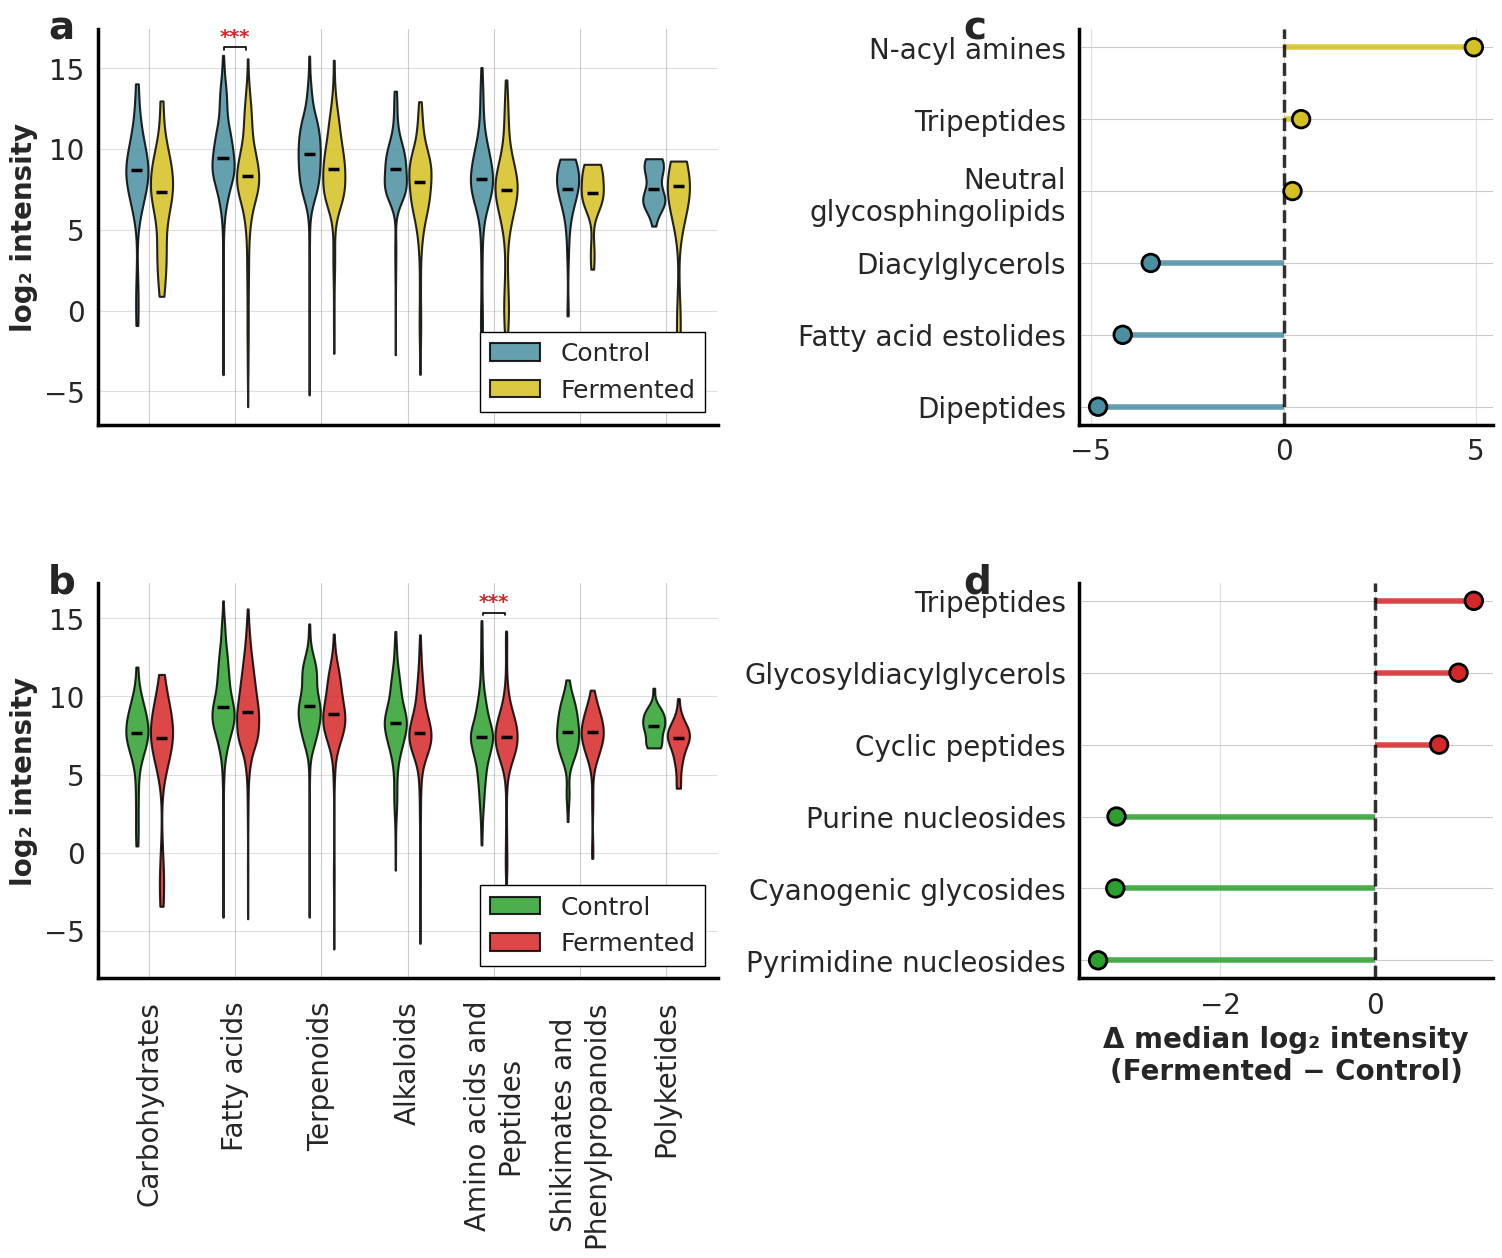

In [72]:
# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 2: NPC PATHWAY VIOLINS (panels a/b) + CLASS LOLLIPOPS (panels c/d)
# Significance values (adjp) and class-level effect sizes are loaded from
# results/canopus_npc_significance.csv, produced by
# scripts/compute_class_significance.py. Run that script to regenerate the
# CSV before re-running this cell.
# ═══════════════════════════════════════════════════════════════════════════

import textwrap
from matplotlib.patches import Patch

# ─── STYLING PARAMETERS ──────────────────────────────────────────────────
LABEL_FONTSIZE = 20
TICK_FONTSIZE = 20
LEGEND_FONTSIZE = 18
PANEL_LABEL_FONTSIZE = 28
VIOLIN_ALPHA = 0.85
LOLLIPOP_ALPHA = 0.85
SPINE_WIDTH = 2.5
GRID_ALPHA = 0.25

# ─── CONFIGURATION ───────────────────────────────────────────────────────
class_col_violin = "sirius_NPC#pathway"
prob_col_violin  = "sirius_NPC#pathway Probability"
MIN_N_VIOLIN     = 5
TOP_N            = 3  # top 3 enriched + top 3 depleted per tuber

cassava_ctrl_cols = [f"CSF_1_rep_{r}_norm_log2" for r in (1,2,3)]
cassava_ferm_cols = [f"CSF_2_rep_{r}_norm_log2" for r in (1,2,3)]
cocoyam_ctrl_cols = [f"CYF_1_rep_{r}_norm_log2" for r in (1,2,3)]
cocoyam_ferm_cols = [f"CYF_2_rep_{r}_norm_log2" for r in (1,2,3)]

cassava_colors = ["#4A8FA0", "#D4C020"]
cocoyam_colors = ["#2ca02c", "#d62728"]

# ─── HELPER FUNCTIONS ────────────────────────────────────────────────────
def build_long(source, cols, class_col, prob_col):
    sub = source[
        (pd.to_numeric(source[prob_col], errors='coerce') >= PROB_CUTOFF) &
        (source[class_col].notna()) & (source[class_col] != "")
    ][[class_col] + cols].copy()
    long = sub.melt(id_vars=class_col, value_vars=cols, value_name="intensity")
    long["intensity"] = pd.to_numeric(long["intensity"], errors="coerce")
    return long.dropna(subset=["intensity"])

def sig_label(p):
    if p is None or np.isnan(p): return "ns"
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

# ─── LOAD SIGNIFICANCE FROM CSV ──────────────────────────────────────────
sig_df = pd.read_csv('../results/canopus_npc_significance.csv')

# ─── PREPARE VIOLIN PLOT DATA ────────────────────────────────────────────
rows_def = [
    {"label": "Cassava", "source": cassava_violin_data,
     "ctrl": cassava_ctrl_cols, "ferm": cassava_ferm_cols, "colors": cassava_colors},
    {"label": "Cocoyam", "source": cocoyam_violin_data,
     "ctrl": cocoyam_ctrl_cols, "ferm": cocoyam_ferm_cols, "colors": cocoyam_colors},
]

for row in rows_def:
    row["ctrl_long"] = build_long(row["source"], row["ctrl"], class_col_violin, prob_col_violin)
    row["ferm_long"] = build_long(row["source"], row["ferm"], class_col_violin, prob_col_violin)

all_pathways = set(rows_def[0]["ctrl_long"][class_col_violin].unique()) | \
               set(rows_def[0]["ferm_long"][class_col_violin].unique())

valid_pathways = [
    p for p in all_pathways
    if all(
        (row[k][class_col_violin] == p).sum() >= MIN_N_VIOLIN
        for row in rows_def
        for k in ["ctrl_long", "ferm_long"]
    )
]

def pathway_median_diff(p):
    ctrl = rows_def[0]["ctrl_long"].loc[rows_def[0]["ctrl_long"][class_col_violin] == p, "intensity"]
    ferm = rows_def[0]["ferm_long"].loc[rows_def[0]["ferm_long"][class_col_violin] == p, "intensity"]
    return ferm.median() - ctrl.median()

pathway_order = sorted(valid_pathways, key=pathway_median_diff)
n_pathways = len(pathway_order)

# ─── SIGNIFICANCE LOOKUP (from CSV, level='pathway') ─────────────────────
def _pathway_adjp(tuber):
    sub = sig_df[(sig_df["tuber"] == tuber) & (sig_df["level"] == "pathway")]
    return dict(zip(sub["name"], sub["adjp"]))

adj_pvals_cassava = _pathway_adjp("Cassava")
adj_pvals_cocoyam = _pathway_adjp("Cocoyam")

print(f"✓ Valid NPC pathways: {n_pathways}")
print("\nCassava pathway significance (adjp < 0.05):")
for p in pathway_order:
    lbl = sig_label(adj_pvals_cassava.get(p, np.nan))
    if lbl != "ns":
        print(f"  {p}: {lbl}  (adj p={adj_pvals_cassava[p]:.4f})")
print("\nCocoyam pathway significance (adjp < 0.05):")
for p in pathway_order:
    lbl = sig_label(adj_pvals_cocoyam.get(p, np.nan))
    if lbl != "ns":
        print(f"  {p}: {lbl}  (adj p={adj_pvals_cocoyam[p]:.4f})")

# ─── LOLLIPOP PLOT DATA (top N classes by |mean log2FC|, from CSV) ──────
# Reads from canopus_npc_significance.csv (produced by
# scripts/compute_class_significance.py). log2fc = mean per-feature log2FC
# for features in the class passing the probability cutoff.
# Top N enriched (positive) + top N depleted (negative) by |log2fc|.
class_df = sig_df[sig_df["level"] == "class"].rename(
    columns={"name": "npc_class", "log2fc": "median_diff"}
)
plot_data = {}
for tuber in ["Cassava", "Cocoyam"]:
    df_t = class_df[class_df["tuber"] == tuber]
    enriched = df_t[df_t["median_diff"] > 0].nlargest(TOP_N, "median_diff")
    depleted = df_t[df_t["median_diff"] < 0].nsmallest(TOP_N, "median_diff")
    plot_data[tuber] = pd.concat([depleted, enriched]).sort_values("median_diff").reset_index(drop=True)
    print(f"  {tuber}: top {TOP_N} depleted + top {TOP_N} enriched NPC classes by mean log2FC")
    print(f"    enriched: {list(enriched['npc_class'])}")
    print(f"    depleted: {list(depleted['npc_class'])}")


# ═════════════════════════════════════════════════════════════════════════
# CREATE FIGURE WITH 4 PANELS (a, b, c, d)
# ═════════════════════════════════════════════════════════════════════════
fig_width = max(18, n_pathways * 1.4)
fig = plt.figure(figsize=(fig_width, 13))
gs = fig.add_gridspec(2, 2, hspace=0.4, wspace=0.7,
                      height_ratios=[1, 1], width_ratios=[1.5, 1],
                      bottom=0.15)

centres = np.arange(n_pathways) * 3.5

# ═════════════════════════════════════════════════════════════════════════
# PANEL A: CASSAVA - NPC Pathway Violin Plot
# ═════════════════════════════════════════════════════════════════════════
ax_a = fig.add_subplot(gs[0, 0])
row = rows_def[0]

for gi, npc_pathway in enumerate(pathway_order):
    for ti, (key, color) in enumerate(zip(["ctrl_long", "ferm_long"], row["colors"])):
        vals = row[key].loc[row[key][class_col_violin] == npc_pathway, "intensity"].values
        if len(vals) < 2:
            continue
        pos = centres[gi] + (ti - 0.5) * 1.0
        parts = ax_a.violinplot([vals], positions=[pos], widths=0.9,
                                showmeans=False, showmedians=True, showextrema=False)
        for pc in parts["bodies"]:
            pc.set_facecolor(color)
            pc.set_edgecolor('black')
            pc.set_alpha(VIOLIN_ALPHA)
            pc.set_linewidth(1.5)
        parts["cmedians"].set_color("black")
        parts["cmedians"].set_linewidth(2.5)

    # Significance bracket (only when significant)
    label = sig_label(adj_pvals_cassava.get(npc_pathway, np.nan))
    if label != "ns":
        ctrl_v = row["ctrl_long"].loc[row["ctrl_long"][class_col_violin] == npc_pathway, "intensity"].dropna().values
        ferm_v = row["ferm_long"].loc[row["ferm_long"][class_col_violin] == npc_pathway, "intensity"].dropna().values
        if len(ctrl_v) >= 2 and len(ferm_v) >= 2:
            y_max = max(np.max(ctrl_v), np.max(ferm_v))
            y_top = y_max + 0.5
            x_l, x_r = centres[gi] - 0.45, centres[gi] + 0.45
            ax_a.plot([x_l, x_l, x_r, x_r], [y_top - 0.15, y_top, y_top, y_top - 0.15],
                      lw=1.2, color="black")
            ax_a.text(centres[gi], y_top + 0.05, label,
                      ha="center", va="bottom", fontsize=14, color="#d62728", fontweight="bold")

ax_a.set_ylabel("log\u2082 intensity", fontsize=LABEL_FONTSIZE, fontweight='bold')
ax_a.tick_params(axis='y', labelsize=TICK_FONTSIZE, width=SPINE_WIDTH, length=6)
ax_a.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
ax_a.spines[['top', 'right']].set_visible(False)
for spine in ['left', 'bottom']:
    ax_a.spines[spine].set_linewidth(SPINE_WIDTH)
    ax_a.spines[spine].set_edgecolor('black')
ax_a.legend(
    handles=[Patch(facecolor=c, alpha=VIOLIN_ALPHA, edgecolor='black', linewidth=1.5, label=l)
             for c, l in zip(row["colors"], ["Control", "Fermented"])],
    fontsize=LEGEND_FONTSIZE, frameon=True, loc="lower right",
    edgecolor='black', framealpha=1, fancybox=False
)
ax_a.grid(axis='y', alpha=GRID_ALPHA, linewidth=0.8, linestyle='-', color='gray')
ax_a.set_axisbelow(True)
ax_a.text(-0.08, 1.05, 'a', transform=ax_a.transAxes,
          fontsize=PANEL_LABEL_FONTSIZE, fontweight='bold', va='top')

# ═════════════════════════════════════════════════════════════════════════
# PANEL B: COCOYAM - NPC Pathway Violin Plot
# ═════════════════════════════════════════════════════════════════════════
ax_b = fig.add_subplot(gs[1, 0], sharex=ax_a)
row = rows_def[1]

for gi, npc_pathway in enumerate(pathway_order):
    for ti, (key, color) in enumerate(zip(["ctrl_long", "ferm_long"], row["colors"])):
        vals = row[key].loc[row[key][class_col_violin] == npc_pathway, "intensity"].values
        if len(vals) < 2:
            continue
        pos = centres[gi] + (ti - 0.5) * 1.0
        parts = ax_b.violinplot([vals], positions=[pos], widths=0.9,
                                showmeans=False, showmedians=True, showextrema=False)
        for pc in parts["bodies"]:
            pc.set_facecolor(color)
            pc.set_edgecolor('black')
            pc.set_alpha(VIOLIN_ALPHA)
            pc.set_linewidth(1.5)
        parts["cmedians"].set_color("black")
        parts["cmedians"].set_linewidth(2.5)

    # Significance bracket (only when significant)
    label = sig_label(adj_pvals_cocoyam.get(npc_pathway, np.nan))
    if label != "ns":
        ctrl_v = row["ctrl_long"].loc[row["ctrl_long"][class_col_violin] == npc_pathway, "intensity"].dropna().values
        ferm_v = row["ferm_long"].loc[row["ferm_long"][class_col_violin] == npc_pathway, "intensity"].dropna().values
        if len(ctrl_v) >= 2 and len(ferm_v) >= 2:
            y_max = max(np.max(ctrl_v), np.max(ferm_v))
            y_top = y_max + 0.5
            x_l, x_r = centres[gi] - 0.45, centres[gi] + 0.45
            ax_b.plot([x_l, x_l, x_r, x_r], [y_top - 0.15, y_top, y_top, y_top - 0.15],
                      lw=1.2, color="black")
            ax_b.text(centres[gi], y_top + 0.05, label,
                      ha="center", va="bottom", fontsize=14, color="#d62728", fontweight="bold")

ax_b.set_ylabel("log\u2082 intensity", fontsize=LABEL_FONTSIZE, fontweight='bold')
ax_b.tick_params(axis='y', labelsize=TICK_FONTSIZE, width=SPINE_WIDTH, length=6)
ax_b.tick_params(axis='x', labelsize=TICK_FONTSIZE, width=SPINE_WIDTH, length=6, pad=10)
ax_b.set_xticks(centres)
ax_b.set_xticklabels([textwrap.fill(p, width=18) for p in pathway_order],
                     rotation=90, ha="center", fontsize=TICK_FONTSIZE)
ax_b.spines[['top', 'right']].set_visible(False)
for spine in ['left', 'bottom']:
    ax_b.spines[spine].set_linewidth(SPINE_WIDTH)
    ax_b.spines[spine].set_edgecolor('black')
ax_b.legend(
    handles=[Patch(facecolor=c, alpha=VIOLIN_ALPHA, edgecolor='black', linewidth=1.5, label=l)
             for c, l in zip(row["colors"], ["Control", "Fermented"])],
    fontsize=LEGEND_FONTSIZE, frameon=True, loc="lower right",
    edgecolor='black', framealpha=1, fancybox=False
)
ax_b.grid(axis='y', alpha=GRID_ALPHA, linewidth=0.8, linestyle='-', color='gray')
ax_b.set_axisbelow(True)
ax_b.text(-0.08, 1.05, 'b', transform=ax_b.transAxes,
          fontsize=PANEL_LABEL_FONTSIZE, fontweight='bold', va='top')

# ═════════════════════════════════════════════════════════════════════════
# PANEL C: CASSAVA - NPC Class Lollipop Plot
# ═════════════════════════════════════════════════════════════════════════
ax_c = fig.add_subplot(gs[0, 1])
df_cassava = plot_data['Cassava']
colors_cassava = {'pos': '#D4C020', 'neg': '#4A8FA0'}
dot_colors = [colors_cassava['pos'] if d > 0 else colors_cassava['neg']
              for d in df_cassava['median_diff']]
y = np.arange(len(df_cassava))

ax_c.hlines(y, 0, df_cassava['median_diff'],
            colors=dot_colors, linewidth=4, alpha=LOLLIPOP_ALPHA)
ax_c.scatter(df_cassava['median_diff'], y,
             color=dot_colors, s=160, zorder=3, edgecolors='black', linewidth=2)
ax_c.axvline(0, color='black', linewidth=2.5, linestyle='--', alpha=0.8)
ax_c.set_yticks(y)
ax_c.set_yticklabels([textwrap.fill(p, width=25) for p in df_cassava['npc_class']],
                     fontsize=TICK_FONTSIZE)
ax_c.tick_params(axis='both', labelsize=TICK_FONTSIZE, width=SPINE_WIDTH, length=6)
ax_c.spines[['top', 'right']].set_visible(False)
for spine in ['left', 'bottom']:
    ax_c.spines[spine].set_linewidth(SPINE_WIDTH)
    ax_c.spines[spine].set_edgecolor('black')
ax_c.grid(axis='x', alpha=GRID_ALPHA, linewidth=0.8, linestyle='-', color='gray')
ax_c.set_axisbelow(True)
ax_c.text(-0.28, 1.05, 'c', transform=ax_c.transAxes,
          fontsize=PANEL_LABEL_FONTSIZE, fontweight='bold', va='top')

# ═════════════════════════════════════════════════════════════════════════
# PANEL D: COCOYAM - NPC Class Lollipop Plot
# ═════════════════════════════════════════════════════════════════════════
ax_d = fig.add_subplot(gs[1, 1])
df_cocoyam = plot_data['Cocoyam']
colors_cocoyam = {'pos': '#d62728', 'neg': '#2ca02c'}
dot_colors = [colors_cocoyam['pos'] if d > 0 else colors_cocoyam['neg']
              for d in df_cocoyam['median_diff']]
y = np.arange(len(df_cocoyam))

ax_d.hlines(y, 0, df_cocoyam['median_diff'],
            colors=dot_colors, linewidth=4, alpha=LOLLIPOP_ALPHA)
ax_d.scatter(df_cocoyam['median_diff'], y,
             color=dot_colors, s=160, zorder=3, edgecolors='black', linewidth=2)
ax_d.axvline(0, color='black', linewidth=2.5, linestyle='--', alpha=0.8)
ax_d.set_yticks(y)
ax_d.set_yticklabels([textwrap.fill(p, width=25) for p in df_cocoyam['npc_class']],
                     fontsize=TICK_FONTSIZE)
ax_d.set_xlabel('\u0394 median log\u2082 intensity\n(Fermented \u2212 Control)',
                fontsize=LABEL_FONTSIZE, fontweight='bold')
ax_d.tick_params(axis='both', labelsize=TICK_FONTSIZE, width=SPINE_WIDTH, length=6)
ax_d.spines[['top', 'right']].set_visible(False)
for spine in ['left', 'bottom']:
    ax_d.spines[spine].set_linewidth(SPINE_WIDTH)
    ax_d.spines[spine].set_edgecolor('black')
ax_d.grid(axis='x', alpha=GRID_ALPHA, linewidth=0.8, linestyle='-', color='gray')
ax_d.set_axisbelow(True)
ax_d.text(-0.28, 1.05, 'd', transform=ax_d.transAxes,
          fontsize=PANEL_LABEL_FONTSIZE, fontweight='bold', va='top')

# ═════════════════════════════════════════════════════════════════════════
# SAVE FIGURE
# ═════════════════════════════════════════════════════════════════════════
plt.subplots_adjust(bottom=0.12)
fig.savefig(f'{OUTPUT_DIR}/figure2_standardized_sig.svg', format='svg', bbox_inches='tight', dpi=300)
fig.savefig(f'{OUTPUT_DIR}/figure2_standardized_sig.png', format='png', bbox_inches='tight', dpi=300)
print(f"\n{'='*70}")
print(f"✓ SAVED: {OUTPUT_DIR}/figure2_standardized_sig.svg")
print(f"✓ SAVED: {OUTPUT_DIR}/figure2_standardized_sig.png")
print(f"{'='*70}")
plt.show()